In [2]:
import pandas as pd
import yaml

with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

df = pd.read_csv("../" + config["dataset"]["raw_path"])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1]:
import pandas as pd
xl = pd.ExcelFile("../data/raw/ecommerce_churn.xlsx")
print(xl.sheet_names)

['Data Dict', 'E Comm']


In [2]:
df_ecom = pd.read_excel("../data/raw/ecommerce_churn.xlsx", sheet_name="E Comm")
print(df_ecom.shape)
df_ecom.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [2]:
import shap
import joblib

# Load the Telco model and preprocessor (SHAP works per-model,
# so we're explaining the winning Logistic Regression model)
model = joblib.load("../saved_models/churn_model.pkl")
preprocessor = joblib.load("../saved_models/preprocessor.pkl")
X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_data.pkl")

# Get feature names after preprocessing (StandardScaler keeps names,
# OneHotEncoder creates new ones like "Contract_One year")
feature_names = preprocessor.get_feature_names_out()

ModuleNotFoundError: No module named 'shap'

In [3]:
import shap
import joblib

model = joblib.load("../saved_models/churn_model.pkl")
preprocessor = joblib.load("../saved_models/preprocessor.pkl")
X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_data.pkl")

feature_names = preprocessor.get_feature_names_out()

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


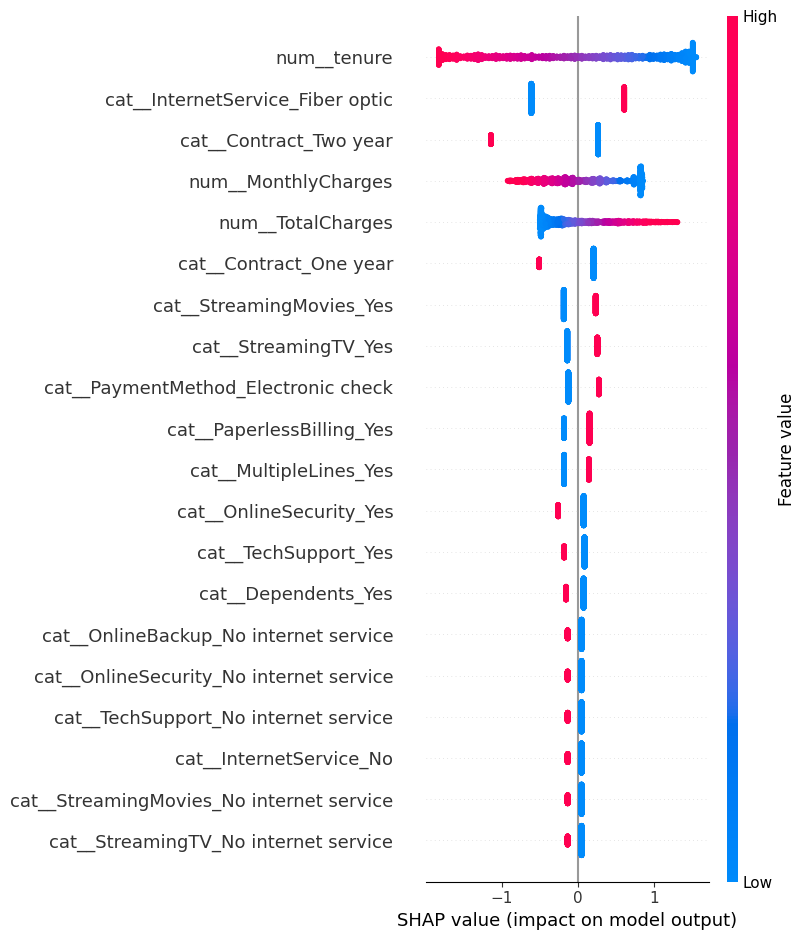

In [4]:
# LinearExplainer is the right choice for Logistic Regression
# (fast, exact — not an approximation like the general-purpose
# KernelExplainer would need to be for arbitrary models)
explainer = shap.LinearExplainer(model, X_train, feature_names=feature_names)
shap_values = explainer(X_test)

# Global feature importance: which features matter most, on average,
# across all test predictions
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

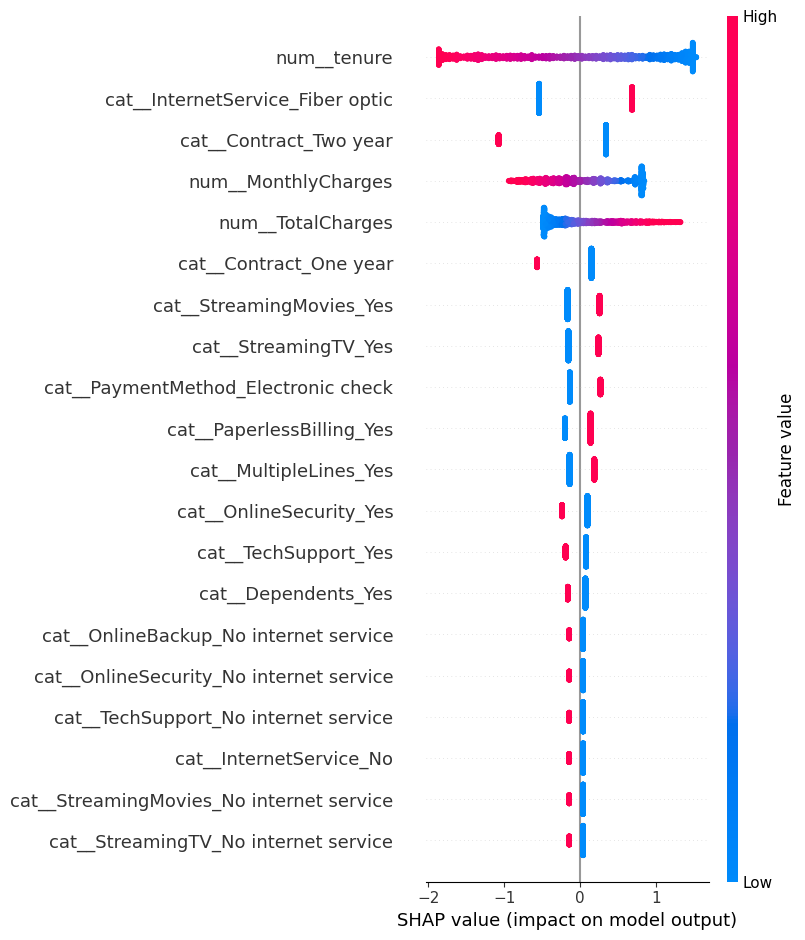

In [5]:
masker = shap.maskers.Independent(X_train, max_samples=X_train.shape[0])
explainer = shap.LinearExplainer(model, masker, feature_names=feature_names)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_names)

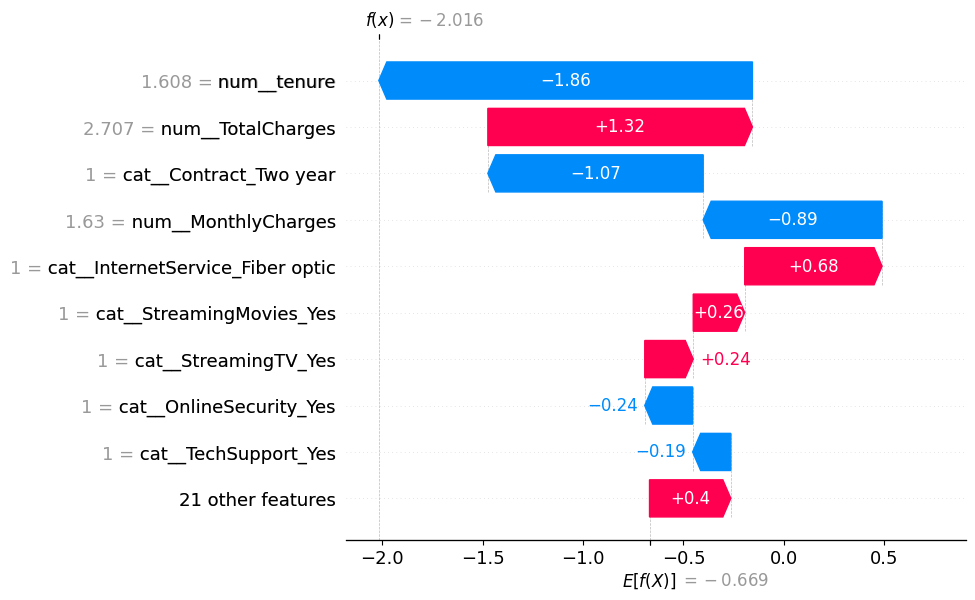

In [6]:
customer_idx = 0
shap.waterfall_plot(shap_values[customer_idx])

In [3]:
print(df_ecom.columns.tolist())
print()
df_ecom.info()

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender   

In [3]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
# Check for non-numeric entries in TotalCharges
non_numeric = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print(f"Rows with non-numeric TotalCharges: {len(non_numeric)}")
non_numeric[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Rows with non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [5]:
# Class balance of the target variable
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


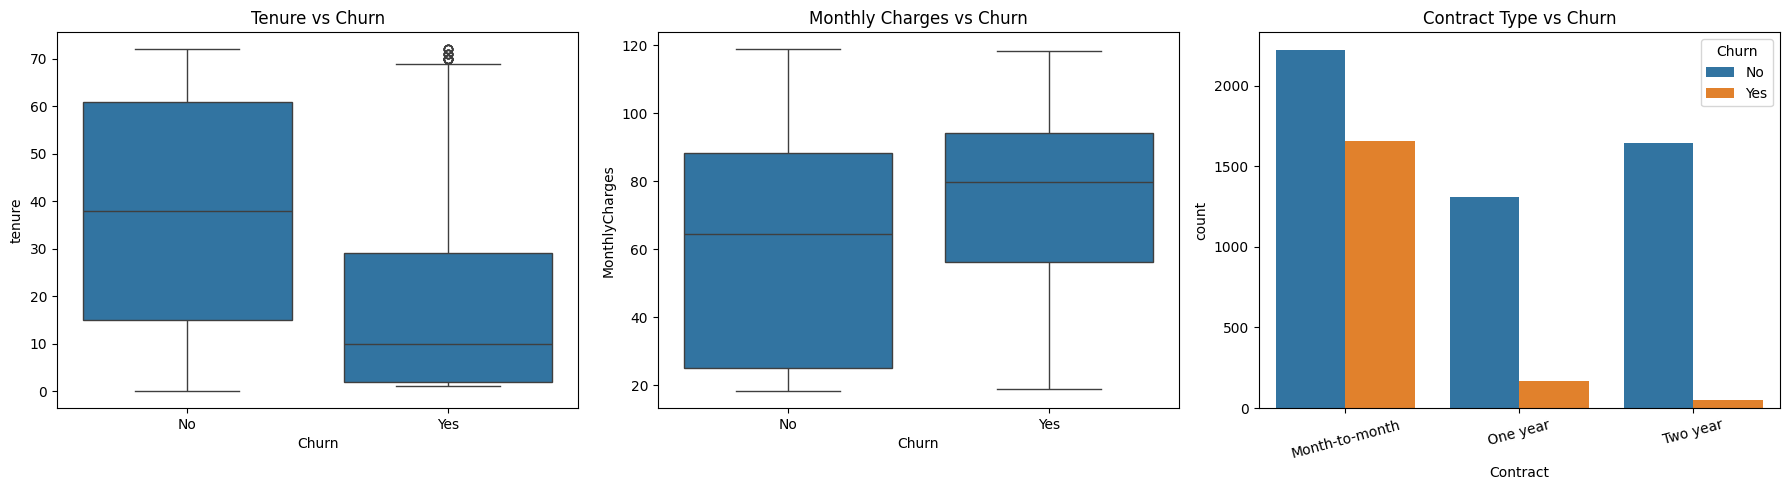

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[2])
axes[2].set_title("Contract Type vs Churn")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [1]:
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Load everything needed for evaluation
all_models = joblib.load("../saved_models/all_models.pkl")
X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_data.pkl")

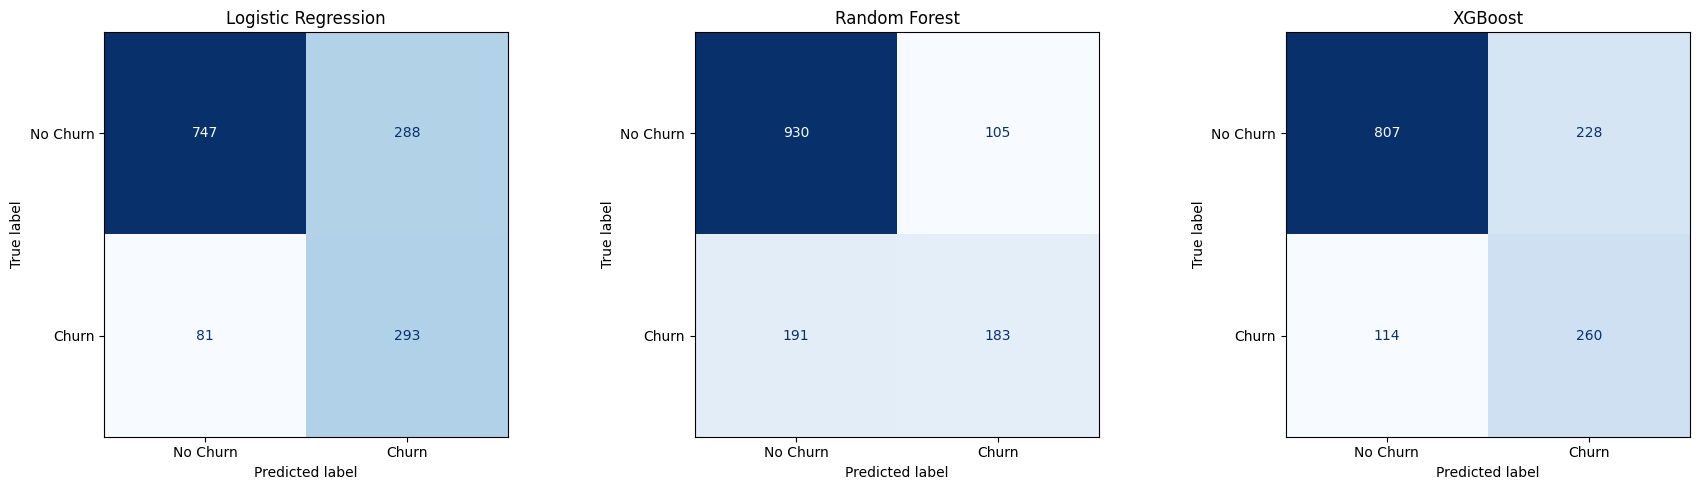

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, all_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

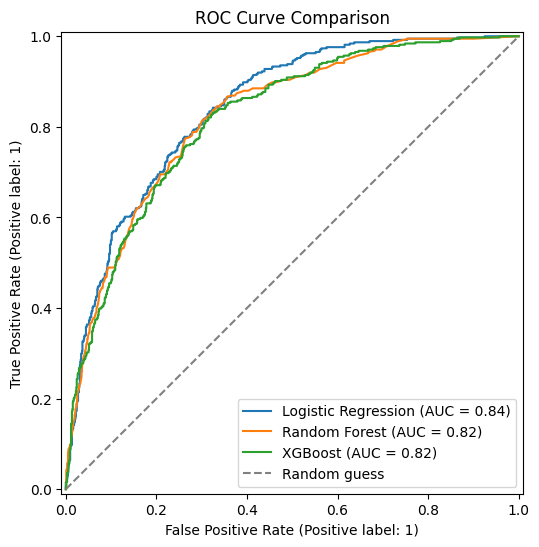

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in all_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

In [4]:
for col in df_ecom.columns:
    print(col)

CustomerID
Churn
Tenure
PreferredLoginDevice
CityTier
WarehouseToHome
PreferredPaymentMode
Gender
HourSpendOnApp
NumberOfDeviceRegistered
PreferedOrderCat
SatisfactionScore
MaritalStatus
NumberOfAddress
Complain
OrderAmountHikeFromlastYear
CouponUsed
OrderCount
DaySinceLastOrder
CashbackAmount


In [5]:
df_ecom.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [1]:
import pandas as pd
df_check = pd.read_excel("../data/raw/ecommerce_churn.xlsx", sheet_name="E Comm")

suspect_cols = ["DaySinceLastOrder", "OrderCount", "CouponUsed", "OrderAmountHikeFromlastYear", "CashbackAmount"]
for col in suspect_cols:
    print(col, "correlation with Churn:", df_check[col].corr(df_check["Churn"]).round(3))

DaySinceLastOrder correlation with Churn: -0.161
OrderCount correlation with Churn: -0.029
CouponUsed correlation with Churn: -0.008
OrderAmountHikeFromlastYear correlation with Churn: -0.01
CashbackAmount correlation with Churn: -0.154


In [2]:
numerical_features = [
    "Tenure", "CityTier", "WarehouseToHome", "HourSpendOnApp",
    "NumberOfDeviceRegistered", "SatisfactionScore", "NumberOfAddress",
    "Complain", "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder", "CashbackAmount"
]

correlations = df_check[numerical_features + ["Churn"]].corr()["Churn"].sort_values()
print(correlations)

Tenure                        -0.349408
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
OrderCount                    -0.028697
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
HourSpendOnApp                 0.018675
NumberOfAddress                0.043931
WarehouseToHome                0.076630
CityTier                       0.084703
SatisfactionScore              0.105481
NumberOfDeviceRegistered       0.107939
Complain                       0.250188
Churn                          1.000000
Name: Churn, dtype: float64


In [3]:
print("Duplicate rows:", df_check.duplicated().sum())
print("Duplicate CustomerIDs:", df_check["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate CustomerIDs: 0
